# EDA And Feature Engineering Of Google Play Store Dataset

1. **Problem statement:** Today, **1.85 million** different apps are available for users to download. Android users have even more from which to choose, with **2.56 million** available through the Google Play Store. These apps have come to play a huge role in the way we live our lives today. Our objective is to find the **Most Popular Category**, find the **App with the largest number of installs**, and the **App with the largest size**, etc.

2. **Data Collection**

The data consists of **20 columns** and **10,841 rows**.

## Steps We Are Going to Follow

1. Data Cleaning
2. Exploratory Data Analysis
3. Feature Engineering

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


%matplotlib inline

In [6]:
df = pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:
df.shape

(10841, 13)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [10]:
##summary of the dataset
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [11]:
##missing values
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

### Insights and observations

the data has missing values

## DATA CLEANING

In [13]:
## check if all the values in numbers of Reviews
df['Reviews'].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'],
      shape=(6002,), dtype=object)

In [16]:
df['Reviews'].astype(int)

ValueError: invalid literal for int() with base 10: '3.0M'

In [14]:
df['Reviews'].str.isnumeric().sum()

np.int64(10840)

In [15]:
df[~df['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [18]:
df_copy=df.copy()

In [22]:
df_copy = df_copy.drop(df_copy.index[10472])

In [23]:
df_copy[~df_copy['Reviews'].str.isnumeric()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [24]:
## convert Reviws Datatype to int
df_copy['Reviews'] = df_copy['Reviews'].astype(int)

In [25]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  object 
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.2+ MB


In [26]:
df_copy['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [28]:
df_copy['Size'].isnull().sum()

np.int64(0)

In [31]:
df_copy['Size']=df_copy['Size'].str.replace('M','000')
df_copy['Size']=df_copy['Size'].str.replace('k','')
df_copy['Size']=df_copy['Size'].replace('Varies with device',np.nan)
df_copy['Size']=df_copy['Size'].astype(float)

In [34]:
df_copy['Size']

0        19000.0
1        14000.0
2            8.7
3        25000.0
4            2.8
          ...   
10836    53000.0
10837        3.6
10838        9.5
10839        NaN
10840    19000.0
Name: Size, Length: 10840, dtype: float64

In [38]:
df_copy['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [39]:
df_copy['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [40]:
chars_to_remove = ['+',',','$']
cols_to_clean = ['Installs','Price']
for item in chars_to_remove:
    for cols in cols_to_clean:
        df_copy[cols] = df_copy[cols].str.replace(item,"")

In [41]:
df_copy['Price'].unique()

array(['0', '4.99', '3.99', '6.99', '1.49', '2.99', '7.99', '5.99',
       '3.49', '1.99', '9.99', '7.49', '0.99', '9.00', '5.49', '10.00',
       '24.99', '11.99', '79.99', '16.99', '14.99', '1.00', '29.99',
       '12.99', '2.49', '10.99', '1.50', '19.99', '15.99', '33.99',
       '74.99', '39.99', '3.95', '4.49', '1.70', '8.99', '2.00', '3.88',
       '25.99', '399.99', '17.99', '400.00', '3.02', '1.76', '4.84',
       '4.77', '1.61', '2.50', '1.59', '6.49', '1.29', '5.00', '13.99',
       '299.99', '379.99', '37.99', '18.99', '389.99', '19.90', '8.49',
       '1.75', '14.00', '4.85', '46.99', '109.99', '154.99', '3.08',
       '2.59', '4.80', '1.96', '19.40', '3.90', '4.59', '15.46', '3.04',
       '4.29', '2.60', '3.28', '4.60', '28.99', '2.95', '2.90', '1.97',
       '200.00', '89.99', '2.56', '30.99', '3.61', '394.99', '1.26',
       '1.20', '1.04'], dtype=object)

In [42]:
df_copy['Installs'].unique()

array(['10000', '500000', '5000000', '50000000', '100000', '50000',
       '1000000', '10000000', '5000', '100000000', '1000000000', '1000',
       '500000000', '50', '100', '500', '10', '1', '5', '0'], dtype=object)

In [44]:
df_copy['Installs'] = df_copy["Installs"].astype('int')
df_copy['Price'] = df_copy["Price"].astype('float')

In [46]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 1.2+ MB


In [47]:
## Handling LAst update feature
df_copy["Last Updated"].unique()

array(['January 7, 2018', 'January 15, 2018', 'August 1, 2018', ...,
       'January 20, 2014', 'February 16, 2014', 'March 23, 2014'],
      shape=(1377,), dtype=object)

In [48]:
df_copy['Last Updated'] = pd.to_datetime(df_copy['Last Updated'])
df_copy['Day'] = df_copy['Last Updated'].dt.day
df_copy['Month'] = df_copy['Last Updated'].dt.month
df_copy['Year'] = df_copy['Last Updated'].dt.year

In [49]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  object        
 1   Category        10840 non-null  object        
 2   Rating          9366 non-null   float64       
 3   Reviews         10840 non-null  int64         
 4   Size            9145 non-null   float64       
 5   Installs        10840 non-null  int64         
 6   Type            10839 non-null  object        
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10840 non-null  object        
 10  Last Updated    10840 non-null  datetime64[ns]
 11  Current Ver     10832 non-null  object        
 12  Android Ver     10838 non-null  object        
 13  Day             10840 non-null  int32         
 14  Month           10840 non-null  int32         
 15  Year   

In [50]:
df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [54]:
df_copy.to_csv("google_cleaned.csv", index=False)

## EDA

In [55]:
df_copy.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018


In [61]:
df_copy[df_copy.duplicated('App')].shape

(1181, 16)

## observation
the dataset has duplicate records

In [64]:
df_copy = df_copy.drop_duplicates(subset=['App'],keep='first')

## Explore data

In [65]:
numeric_features = [feature for feature in df_copy.columns if df_copy[feature].dtype != 'O']
categorical_features = [feature for feature in df_copy.columns if df_copy[feature].dtype == 'O']

# print columns
print("We have {} numerical features : {}".format(len(numeric_features), numeric_features))
print("\nWe have {} categorical features : {}".format(len(categorical_features), categorical_features))

We have 9 numerical features : ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Last Updated', 'Day', 'Month', 'Year']

We have 7 categorical features : ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']


## 3.2 Feature Information

1. App :- Name of the App
2. Category :- Category under which the App falls.
3. Rating :- Application's rating on Play Store
4. Reviews :- Number of reviews of the App.
5. Size :- Size of the App.
6. Install :- Number of Installs of the App
7. Type :- If the App is free/paid
8. Price :- Price of the App (0 if it is Free)
9. Content Rating :- Appropriate Target Audience of the App.
10. Genres :- Genre under which the App falls.
11. Last Updated :- Date when the App was last updated
12. Current Ver :- Current Version of the Application
13. Android Ver :- Minimum Android Version required to run the App

In [68]:
## Proportion of count data on categorical columns
for col in categorical_features:
    print(df_copy[col].value_counts(normalize=True)*100)
    print('-------------------')

App
Photo Editor & Candy Camera & Grid & ScrapBook        0.010353
Coloring book moana                                   0.010353
U Launcher Lite – FREE Live Cool Themes, Hide Apps    0.010353
Sketch - Draw & Paint                                 0.010353
Pixel Draw - Number Art Coloring Book                 0.010353
                                                        ...   
Sya9a Maroc - FR                                      0.010353
Fr. Mike Schmitz Audio Teachings                      0.010353
Parkinson Exercices FR                                0.010353
The SCP Foundation DB fr nn5n                         0.010353
iHoroscope - 2018 Daily Horoscope & Astrology         0.010353
Name: proportion, Length: 9659, dtype: float64
-------------------
Category
FAMILY                 18.966767
GAME                    9.928564
TOOLS                   8.561963
BUSINESS                4.348276
MEDICAL                 4.089450
PERSONALIZATION         3.892743
PRODUCTIVITY            3.872

C:\Users\ARNAV MAHAJAN\AppData\Local\Temp\ipykernel_5236\3940581089.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df_copy[numeric_features[i]], shade=True, color='r')
C:\Users\ARNAV MAHAJAN\AppData\Local\Temp\ipykernel_5236\3940581089.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df_copy[numeric_features[i]], shade=True, color='r')
C:\Users\ARNAV MAHAJAN\AppData\Local\Temp\ipykernel_5236\3940581089.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=df_copy[numeric_features[i]], shade=True, color='r')
C:\Users\ARNAV MAHAJAN\AppData\Local\Temp\ipykernel_5236\3940581089.py:7: FutureWarning: 

`shade` is n

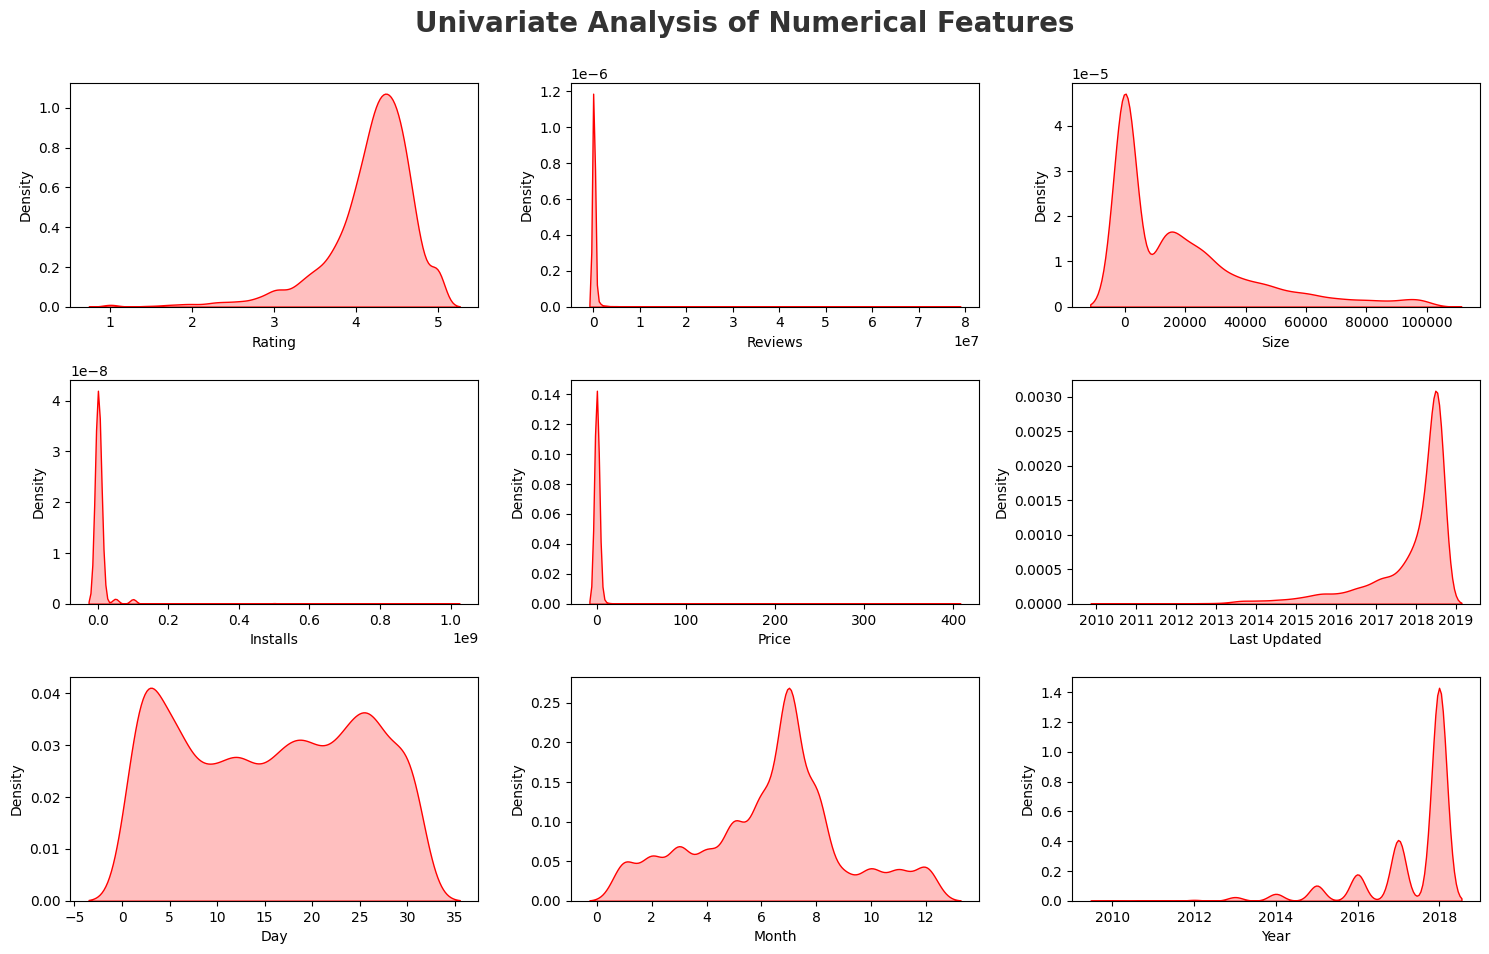

In [69]:
## Proportion of count data on numerical columns
plt.figure(figsize=(15, 15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df_copy[numeric_features[i]], shade=True, color='r')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

## Observations

- Rating and Year is left skewed while Reviews, Size, Installs and Price are right skewed.

C:\Users\ARNAV MAHAJAN\AppData\Local\Temp\ipykernel_5236\1766111854.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[category[i]], palette="Set2")
C:\Users\ARNAV MAHAJAN\AppData\Local\Temp\ipykernel_5236\1766111854.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[category[i]], palette="Set2")


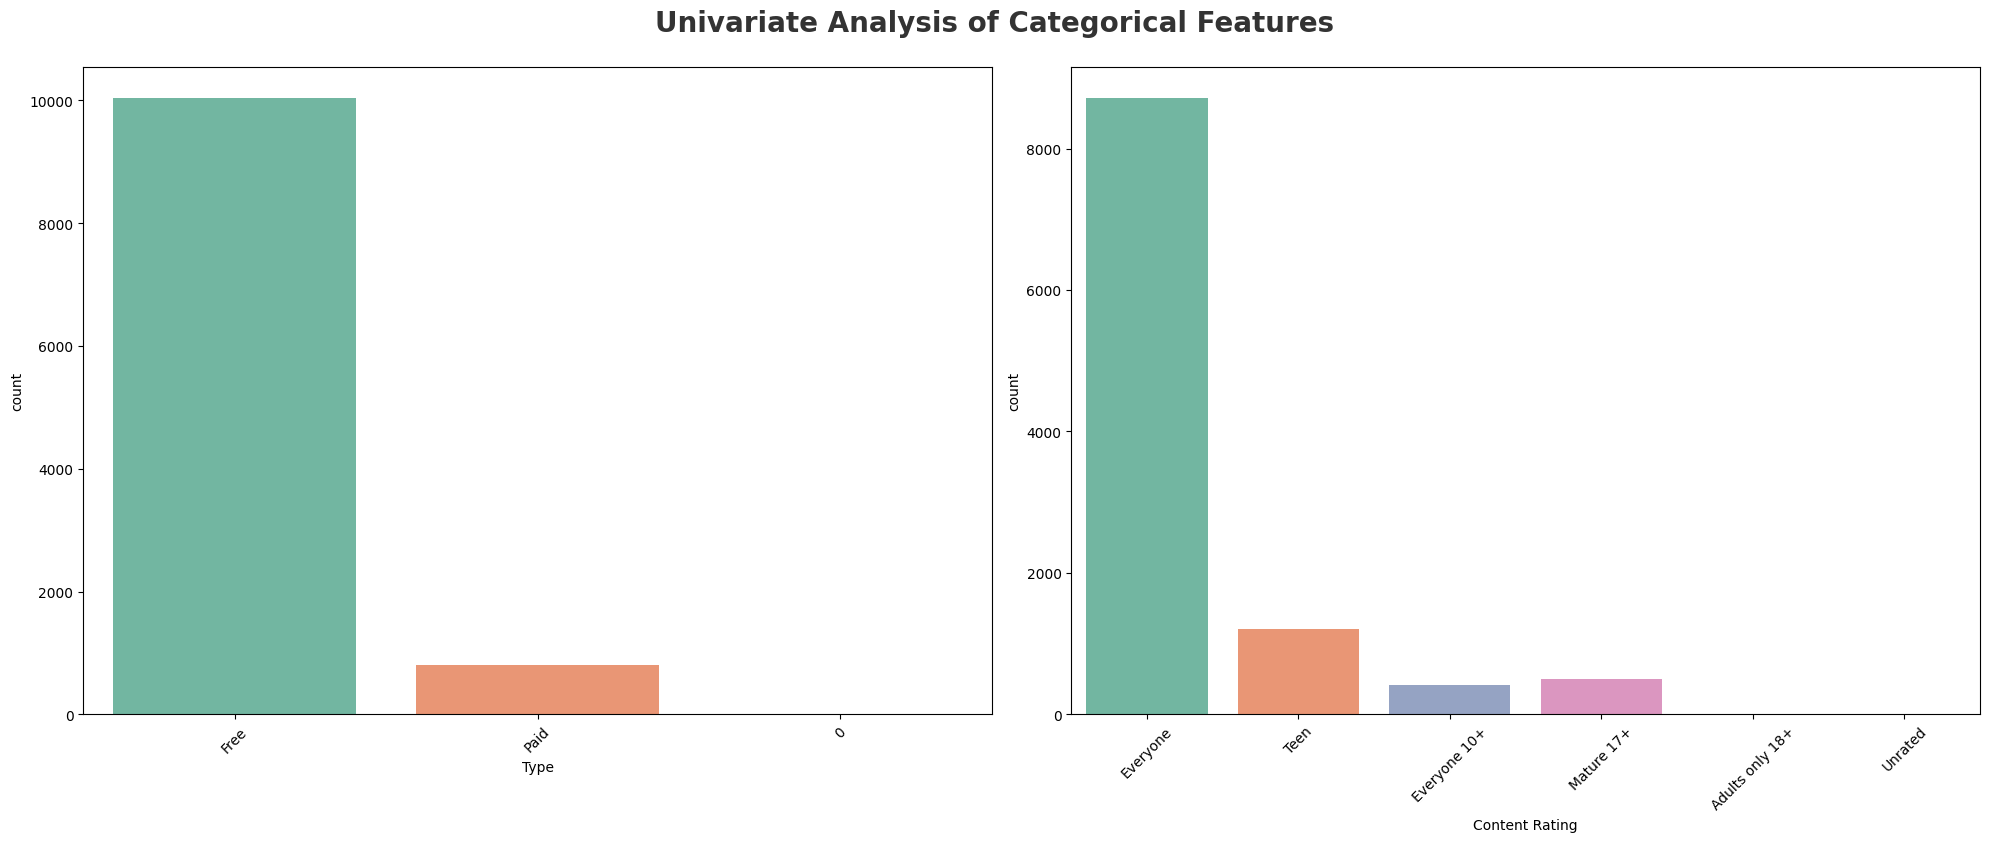

In [70]:
# categorical columns
plt.figure(figsize=(20, 15))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

category = ['Type', 'Content Rating']

for i in range(0, len(category)):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=df[category[i]], palette="Set2")
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

### which is the most popular app category

In [71]:
df_copy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018


<Axes: ylabel='count'>

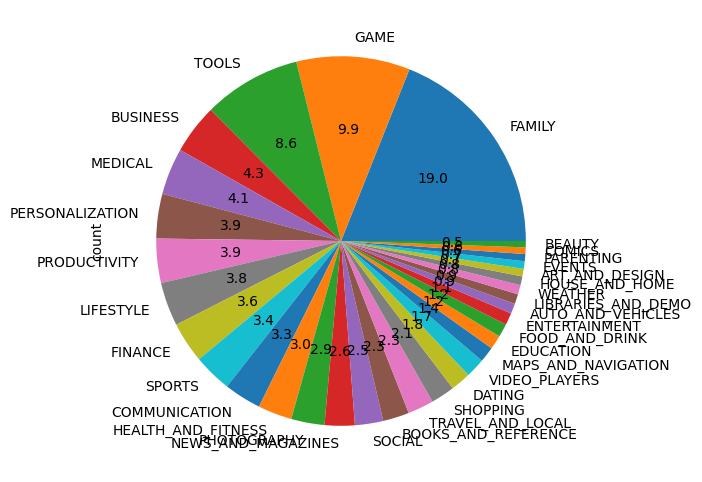

In [73]:
df_copy['Category'].value_counts().plot.pie(y=df_copy['Category'], figsize=(15, 6),autopct='%1.1f')

## Observations

- There are more kinds of apps in Play Store which are under the categories of **Family**, **Games**, and **Tools**.
- **Beauty**, **Comics**, **Arts**, and **Weather** apps are available in much smaller numbers on the Play Store.

In [74]:
## Top 10 App Categories

category = pd.DataFrame(df['Category'].value_counts())   # DataFrame of apps on the basis of category
category.rename(columns={'Category': 'Count'}, inplace=True)

In [75]:
category

,count
Category,
FAMILY,1972
GAME,1144
TOOLS,843
MEDICAL,463
BUSINESS,460
PRODUCTIVITY,424
PERSONALIZATION,392
COMMUNICATION,387
SPORTS,384


C:\Users\ARNAV MAHAJAN\AppData\Local\Temp\ipykernel_5236\3090728398.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category.head(10), x='Category', y='Count', palette='hls')


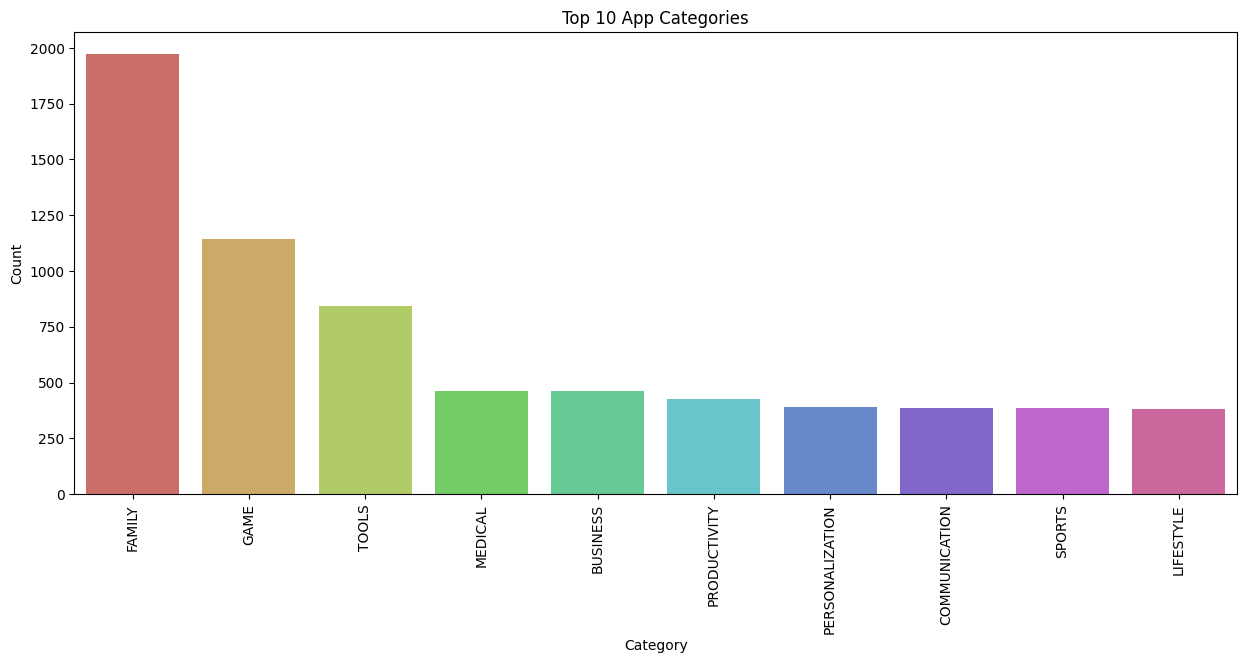

In [78]:
category = df['Category'].value_counts().reset_index()
category.columns = ['Category', 'Count']

plt.figure(figsize=(15, 6))
sns.barplot(data=category.head(10), x='Category', y='Count', palette='hls')
plt.xticks(rotation=90)
plt.title('Top 10 App Categories')
plt.show()

## Insights

- **Family** category has the highest number of apps, with approximately **18%** of all apps belonging to it, followed by the **Games** category, which accounts for around **11%** of the apps.
- The **Beauty** category has the fewest apps, representing **less than 1%** of the total apps in the dataset.

## Internal Assignments

1. Which category has the largest number of installations?
2. What are the Top 5 most installed apps in each popular category?
3. How many apps on the Google Play Store have a rating of 5?
4. Which app has the highest number of installs?
5. Which app has received the highest number of reviews?
6. Which category has the highest average app rating?
7. Which category contains the maximum number of apps?
8. Which category contains the minimum number of apps?
9. How many Free and Paid apps are available on the Google Play Store?
10. Which paid app has the highest price?
11. Which category contains the most paid apps?
12. Which category contains the most free apps?
13. What is the average size of apps in each category?
14. Which content rating has the highest number of apps?
15. Which genre has the maximum number of apps?
16. Which Android version is required by the highest number of apps?
17. Which current app version appears most frequently in the dataset?
18. What is the average number of installs for each category?
19. Which category generates the highest total revenue potential (Price × Installs)?
20. How many apps were updated in each year?
21. Which month has the highest number of app updates?
22. Which day of the month has the maximum number of app updates?
23. Which apps have ratings greater than 4.5 and more than 10 million installs?

In [79]:
category_install = (
    df_copy.groupby('Category')['Installs']
    .sum()
    .sort_values(ascending=False)
)

print(category_install)

Category
GAME                   13878924415
COMMUNICATION          11038276251
TOOLS                   8001771915
PRODUCTIVITY            5793091369
SOCIAL                  5487867902
PHOTOGRAPHY             4649147655
FAMILY                  4427941505
VIDEO_PLAYERS           3926902720
TRAVEL_AND_LOCAL        2894887146
NEWS_AND_MAGAZINES      2369217760
ENTERTAINMENT           2113660000
BOOKS_AND_REFERENCE     1665969576
PERSONALIZATION         1532494782
SHOPPING                1400348785
HEALTH_AND_FITNESS      1144022512
SPORTS                  1096474498
BUSINESS                 697164865
LIFESTYLE                503823539
MAPS_AND_NAVIGATION      503281890
FINANCE                  455348734
WEATHER                  361100520
EDUCATION                352952000
FOOD_AND_DRINK           211798751
DATING                   140926107
ART_AND_DESIGN           114338100
HOUSE_AND_HOME            97212461
AUTO_AND_VEHICLES         53130211
LIBRARIES_AND_DEMO        52995910
COMICS     

In [80]:
top5_apps = (
    df_copy.sort_values(['Category', 'Installs'], ascending=[True, False])
           .groupby('Category')
           .head(5)
)

top5_apps[['Category', 'App', 'Installs']]

,Category,App,Installs
3,ART_AND_DESIGN,Sketch - Draw & Paint,50000000
12,ART_AND_DESIGN,Tattoo Name On My Photo Editor,10000000
19,ART_AND_DESIGN,ibis Paint X,10000000
42,ART_AND_DESIGN,Textgram - write on photos,10000000
45,ART_AND_DESIGN,"Canva: Poster, banner, card maker & graphic de...",10000000
...,...,...,...
3626,WEATHER,The Weather Channel: Rain Forecast & Storm Alerts,50000000
3628,WEATHER,AccuWeather: Daily Forecast & Live Weather Rep...,50000000
3649,WEATHER,"GO Weather - Widget, Theme, Wallpaper, Efficient",50000000
4725,WEATHER,Weather & Clock Widget for Android,50000000


In [81]:
five_rating_apps = df_copy[df_copy['Rating'] == 5]

print("Number of apps with Rating = 5 :", len(five_rating_apps))

Number of apps with Rating = 5 : 271


In [87]:
df_copy[['App', 'Installs']].sort_values('Installs', ascending=False).head()

,App,Installs
2545,Instagram,1000000000
3127,Google Street View,1000000000
152,Google Play Books,1000000000
1654,Subway Surfers,1000000000
3454,Google Drive,1000000000


In [88]:
df_copy[['App', 'Reviews']].sort_values('Reviews', ascending=False).head()

,App,Reviews
2544,Facebook,78158306
336,WhatsApp Messenger,69119316
2545,Instagram,66577313
335,Messenger – Text and Video Chat for Free,56642847
1670,Clash of Clans,44891723


In [90]:
df_copy.groupby('Category')['Rating'].mean().sort_values(ascending=False).head()

Category
EVENTS                 4.435556
EDUCATION              4.364407
ART_AND_DESIGN         4.357377
BOOKS_AND_REFERENCE    4.344970
PERSONALIZATION        4.332215
Name: Rating, dtype: float64

In [91]:
df_copy['Category'].value_counts().head(1)

Category
FAMILY    1832
Name: count, dtype: int64

In [92]:
df_copy['Category'].value_counts().tail(1)

Category
BEAUTY    53
Name: count, dtype: int64

In [93]:
df_copy['Type'].value_counts()

Type
Free    8902
Paid     756
Name: count, dtype: int64

In [95]:
df_copy[df_copy['Type'] == 'Paid'][['App', 'Price']].sort_values('Price', ascending=False).head(10)

,App,Price
4367,I'm Rich - Trump Edition,400.00
5364,I am rich (Most expensive app),399.99
5369,I am Rich,399.99
4362,💎 I'm rich,399.99
5359,I am rich(premium),399.99
5358,I am Rich!,399.99
5354,I am Rich Plus,399.99
5373,I AM RICH PRO PLUS,399.99
4197,most expensive app (H),399.99
5362,I Am Rich Pro,399.99


In [96]:
df_copy[df_copy['Type'] == 'Free']['Category'].value_counts().head(1)

Category
FAMILY    1648
Name: count, dtype: int64

In [97]:
df_copy.groupby('Category')['Size'].mean().sort_values(ascending=False)

Category
GAME                   41276.020733
FAMILY                 25499.237949
TRAVEL_AND_LOCAL       22708.220231
SPORTS                 22393.010877
ENTERTAINMENT          21595.200000
PARENTING              20113.512963
FOOD_AND_DRINK         19171.778409
HEALTH_AND_FITNESS     18166.609052
AUTO_AND_VEHICLES      17923.262667
MEDICAL                17477.526087
EDUCATION              17294.820225
FINANCE                15361.106020
MAPS_AND_NAVIGATION    13830.474766
VIDEO_PLAYERS          13457.298425
SHOPPING               13336.448810
SOCIAL                 13292.604233
PHOTOGRAPHY            13128.607658
DATING                 12971.359119
HOUSE_AND_HOME         12836.298387
LIFESTYLE              12414.714072
COMICS                 11656.283673
EVENTS                 11587.185965
BUSINESS               11270.856915
BEAUTY                 10939.029787
BOOKS_AND_REFERENCE    10169.627835
WEATHER                10102.258929
PRODUCTIVITY            9888.604124
NEWS_AND_MAGAZINES 

In [98]:
df_copy['Content Rating'].value_counts().head()

Content Rating
Everyone           7903
Teen               1036
Mature 17+          393
Everyone 10+        322
Adults only 18+       3
Name: count, dtype: int64

In [108]:
for rating, data in df_copy.groupby('Content Rating'):
    print(f"\nContent Rating: {rating}")
    print(data['App'].tolist())


Content Rating: Adults only 18+
['Manga Master - Best manga & comic reader', 'DraftKings - Daily Fantasy Sports', 'Manga Books']

Content Rating: Everyone
['Photo Editor & Candy Camera & Grid & ScrapBook', 'Coloring book moana', 'U Launcher Lite – FREE Live Cool Themes, Hide Apps', 'Pixel Draw - Number Art Coloring Book', 'Paper flowers instructions', 'Smoke Effect Photo Maker - Smoke Editor', 'Infinite Painter', 'Garden Coloring Book', 'Kids Paint Free - Drawing Fun', 'Text on Photo - Fonteee', 'Name Art Photo Editor - Focus n Filters', 'Mandala Coloring Book', '3D Color Pixel by Number - Sandbox Art Coloring', 'Learn To Draw Kawaii Characters', 'Photo Designer - Write your name with shapes', '350 Diy Room Decor Ideas', 'FlipaClip - Cartoon animation', 'ibis Paint X', 'Logo Maker - Small Business', "Boys Photo Editor - Six Pack & Men's Suit", 'Mcqueen Coloring pages', 'HD Mickey Minnie Wallpapers', 'Harley Quinn wallpapers HD', 'Colorfit - Drawing & Coloring', 'Animated Photo Editor'

In [99]:
df_copy['Genres'].value_counts().head(1)

Genres
Tools    826
Name: count, dtype: int64

In [100]:
df_copy['Android Ver'].value_counts().head(1)

Android Ver
4.1 and up    2202
Name: count, dtype: int64

In [101]:
df_copy['Current Ver'].value_counts().head(1)

Current Ver
Varies with device    1055
Name: count, dtype: int64

In [102]:
df_copy.groupby('Category')['Installs'].mean().sort_values(ascending=False)

Category
COMMUNICATION          3.504215e+07
VIDEO_PLAYERS          2.409143e+07
SOCIAL                 2.296179e+07
ENTERTAINMENT          2.072216e+07
PHOTOGRAPHY            1.654501e+07
PRODUCTIVITY           1.548955e+07
GAME                   1.447229e+07
TRAVEL_AND_LOCAL       1.321866e+07
TOOLS                  9.675661e+06
NEWS_AND_MAGAZINES     9.327629e+06
BOOKS_AND_REFERENCE    7.504367e+06
SHOPPING               6.932420e+06
WEATHER                4.570893e+06
PERSONALIZATION        4.075784e+06
HEALTH_AND_FITNESS     3.972300e+06
MAPS_AND_NAVIGATION    3.841846e+06
SPORTS                 3.373768e+06
EDUCATION              2.965983e+06
FAMILY                 2.416999e+06
FOOD_AND_DRINK         1.891060e+06
ART_AND_DESIGN         1.786533e+06
BUSINESS               1.659916e+06
LIFESTYLE              1.365375e+06
FINANCE                1.319851e+06
HOUSE_AND_HOME         1.313682e+06
DATING                 8.241293e+05
COMICS                 8.032348e+05
LIBRARIES_AND_DEMO 

In [103]:
df_copy['Revenue'] = df_copy['Price'] * df_copy['Installs']

df_copy.groupby('Category')['Revenue'].sum().sort_values(ascending=False).head(1)

C:\Users\ARNAV MAHAJAN\AppData\Local\Temp\ipykernel_5236\4212647772.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy['Revenue'] = df_copy['Price'] * df_copy['Installs']


Category
FAMILY    1.136798e+08
Name: Revenue, dtype: float64

In [104]:
df_copy['Year'].value_counts().sort_index()

Year
2010       1
2011      15
2012      26
2013     108
2014     203
2015     449
2016     779
2017    1794
2018    6284
Name: count, dtype: int64

In [105]:
df_copy['Month'].value_counts().head(1)

Month
7    2612
Name: count, dtype: int64

In [106]:
df_copy['Day'].value_counts().head(1)

Day
3    517
Name: count, dtype: int64

In [107]:
df_copy[
    (df_copy['Rating'] > 4.5) &
    (df_copy['Installs'] > 10000000)
][['App', 'Category', 'Rating', 'Installs']]

,App,Category,Rating,Installs
139,Wattpad 📖 Free Books,BOOKS_AND_REFERENCE,4.6,100000000
371,Google Duo - High Quality Video Calls,COMMUNICATION,4.6,500000000
413,"CM Browser - Ad Blocker , Fast Download , Privacy",COMMUNICATION,4.6,50000000
459,Mail.Ru - Email App,COMMUNICATION,4.6,50000000
699,Duolingo: Learn Languages Free,EDUCATION,4.7,100000000
...,...,...,...,...
7536,"Security Master - Antivirus, VPN, AppLock, Boo...",TOOLS,4.7,500000000
7540,Clean Master Lite - For Low-End Phone,TOOLS,4.6,50000000
7808,CamScanner - Phone PDF Creator,PRODUCTIVITY,4.6,100000000
8175,Master for Minecraft(Pocket Edition)-Mod Launcher,TOOLS,4.6,50000000


In [109]:
top_10_games = (
    df_copy[df_copy['Category'] == 'GAME']
    .sort_values(by='Rating', ascending=False)
    .head(10)
)

top_10_games[['App', 'Rating', 'Reviews', 'Installs']]

,App,Rating,Reviews,Installs
5917,Ra Ga Ba,5.0,2,1
5795,Axe Champs! Wars,5.0,8,50
9056,Santa's Monster Shootout DX,5.0,4,50
7466,211:CK,5.0,8,10
6700,Brick Breaker BR,5.0,7,5
7698,CP Trivia,5.0,5,100
7402,Trovami se ci riesci,5.0,11,10
10776,Monster Ride Pro,5.0,1,10
5822,Flippy Axe : Flip The Knife & Axe Simulator,5.0,7,100
10697,Mu.F.O.,5.0,2,1
